<a href="https://colab.research.google.com/github/adindachyaa/hehe/blob/main/UTS_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAHAP 1 — Baca dan Eksplorasi Data Sensor CD

**Tujuan Tahap Ini:**
- Upload semua file data sensor ke Google Colab
- Baca semua file Excel dari 16 folder (15 konsentrasi Cd + 1 blanko KCL)
- Pahami struktur data dan tampilkan visualisasi awal
- Siapkan dataset yang siap dipakai untuk Tahap 2 (Preprocessing)

## 📦 SEL 1 — Install dan Import Library

Library adalah kumpulan kode siap pakai yang memudahkan pekerjaan kita.
- **pandas** → untuk tabel data (seperti Excel tapi di Python)
- **numpy** → untuk kalkulasi matematika
- **matplotlib** → untuk membuat grafik
- **openpyxl** → untuk membaca file `.xlsx`
- **tqdm** → untuk menampilkan progress bar saat membaca ratusan file

In [1]:
# Install library yang mungkin belum ada di Colab
!pip install openpyxl tqdm -q

# Import semua library yang dibutuhkan
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import openpyxl
from tqdm import tqdm
from google.colab import files
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan grafik agar lebih rapi
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## 📁 SEL 2 — Upload dan Ekstrak File ZIP

Di sini kita upload file ZIP berisi semua data sensor.
Setelah upload, ZIP akan diekstrak otomatis sehingga kita bisa akses semua foldernya.

> ⚠️ **Penting:** Upload file `data_cd_groundturth.zip` (bukan file satuan)

In [2]:
# ======================================================
# UPLOAD FILE ZIP
# Akan muncul tombol "Choose Files" — klik dan pilih
# file 'data_cd_groundturth.zip' dari komputer kamu
# ======================================================
print('📤 Silakan upload file ZIP data sensor...')
uploaded = files.upload()

# Ambil nama file yang diupload
zip_filename = list(uploaded.keys())[0]
print(f'\n✅ File berhasil diupload: {zip_filename}')
print('📂 Mengekstrak file ZIP...')

# Ekstrak ZIP ke folder 'data_sensor'
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('data_sensor')

print('✅ Ekstraksi selesai!')
print('\n📁 Isi folder setelah ekstraksi:')
for item in os.listdir('data_sensor'):
    print(f'  └── {item}')

📤 Silakan upload file ZIP data sensor...


Saving UTS AI C.zip to UTS AI C (1).zip

✅ File berhasil diupload: UTS AI C (1).zip
📂 Mengekstrak file ZIP...
✅ Ekstraksi selesai!

📁 Isi folder setelah ekstraksi:
  └── Template Tugas.docx
  └── Soal UTS.pdf
  └── Alat Sensor CD Groundturth


## 🔍 SEL 3 — Deteksi Struktur Folder Otomatis

Kita cari folder data yang benar, lalu tampilkan daftar semua konsentrasi
beserta jumlah file di tiap folder.

Data terdiri dari:
- **KCL** → blanko/baseline (0 ppm, tanpa Kadmium)
- **2, 4, 6, 8, 10, 20, 40, 60, 80, 100, 200, 400, 600, 800, 1000** → berbagai konsentrasi Kadmium (ppm)

In [3]:
# ======================================================
# DETEKSI FOLDER DATA SECARA OTOMATIS
# Script ini mencari folder yang berisi file .xlsx
# ======================================================

def find_data_root(base_path):
    """Mencari folder root yang berisi sub-folder konsentrasi."""
    # Cek satu level
    for item in os.listdir(base_path):
        full = os.path.join(base_path, item)
        if os.path.isdir(full):
            # Cek apakah isinya folder konsentrasi (berisi xlsx)
            for sub in os.listdir(full):
                sub_full = os.path.join(full, sub)
                if os.path.isdir(sub_full):
                    xlsx_files = [f for f in os.listdir(sub_full) if f.endswith('.xlsx')]
                    if xlsx_files:
                        return full
    return base_path

DATA_ROOT = find_data_root('data_sensor')
print(f'📂 Folder data ditemukan: {DATA_ROOT}')

# Konsentrasi yang valid (angka = ppm, KCL = blanko)
KONSENTRASI_VALID = ['KCL', '2', '4', '6', '8', '10', '20', '40',
                     '60', '80', '100', '200', '400', '600', '800', '1000']

# Mapping folder → nilai ppm (KCL = 0 ppm)
PPM_MAP = {'KCL': 0, '2': 2, '4': 4, '6': 6, '8': 8, '10': 10,
           '20': 20, '40': 40, '60': 60, '80': 80, '100': 100,
           '200': 200, '400': 400, '600': 600, '800': 800, '1000': 1000}

# Scan semua folder dan hitung file xlsx di masing-masing
folder_info = {}
for folder_name in KONSENTRASI_VALID:
    folder_path = os.path.join(DATA_ROOT, folder_name)
    if os.path.isdir(folder_path):
        xlsx_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.xlsx')])
        folder_info[folder_name] = {
            'path': folder_path,
            'files': xlsx_files,
            'count': len(xlsx_files),
            'ppm': PPM_MAP[folder_name]
        }

# Tampilkan ringkasan
print(f'\n{'='*55}')
print(f'{'Folder':^10} | {'Konsentrasi':^15} | {'Jumlah File':^12}')
print(f'{'='*55}')
total_files = 0
for folder_name in KONSENTRASI_VALID:
    if folder_name in folder_info:
        info = folder_info[folder_name]
        label = 'Blanko (KCL)' if folder_name == 'KCL' else f'{info["ppm"]} ppm'
        print(f'{folder_name:^10} | {label:^15} | {info["count"]:^12}')
        total_files += info['count']
print(f'{'='*55}')
print(f'{'TOTAL':^10} | {len(folder_info):^15} konsentrasi | {total_files:^12} file')
print(f'\n✅ Siap membaca {total_files} file dari {len(folder_info)} konsentrasi!')

📂 Folder data ditemukan: data_sensor/Alat Sensor CD Groundturth

  Folder   |   Konsentrasi   | Jumlah File 
   KCL     |  Blanko (KCL)   |      50     
    2      |      2 ppm      |      50     
    4      |      4 ppm      |      50     
    6      |      6 ppm      |      50     
    8      |      8 ppm      |      50     
    10     |     10 ppm      |      50     
    20     |     20 ppm      |      50     
    40     |     40 ppm      |      50     
    60     |     60 ppm      |      49     
    80     |     80 ppm      |      48     
   100     |     100 ppm     |      50     
   200     |     200 ppm     |      50     
   400     |     400 ppm     |      50     
   600     |     600 ppm     |      50     
   800     |     800 ppm     |      50     
   1000    |    1000 ppm     |      50     
  TOTAL    |       16        konsentrasi |     797      file

✅ Siap membaca 797 file dari 16 konsentrasi!


## 📖 SEL 4 — Fungsi Pembaca File Excel

Setiap file `.xlsx` berisi **10 scan** Cyclic Voltammetry (CV).
Struktur setiap file:
```
Baris 1 → Nama scan: "CV i vs E Scan 1" ... "CV i vs E Scan 10"
Baris 2 → Header kolom: V, µA, V, µA, ... (20 kolom total)
Baris 3+ → Data: tegangan (V) dan arus (µA) per titik pengukuran
```
Kita akan fokus pada **Scan 10** karena merupakan scan paling stabil
(sensor butuh beberapa scan awal untuk 'pemanasan').

In [4]:
# ======================================================
# FUNGSI MEMBACA SATU FILE EXCEL
# ======================================================

def baca_file_cv(filepath):
    """
    Membaca satu file Excel data Cyclic Voltammetry.

    Setiap file punya 10 scan, masing-masing punya 2 kolom:
    - Kolom ganjil  = Tegangan / Voltage (V)
    - Kolom genap   = Arus / Current (µA)

    Return: dictionary berisi data semua scan
    """
    try:
        wb = openpyxl.load_workbook(filepath, read_only=True, data_only=True)
        ws = wb.active

        hasil = {}

        # Baca 10 scan (setiap scan = 2 kolom)
        for scan_idx in range(10):
            col_v = scan_idx * 2 + 1   # Kolom tegangan (1, 3, 5, ...)
            col_a = scan_idx * 2 + 2   # Kolom arus (2, 4, 6, ...)

            voltages = []
            currents = []

            # Baca mulai baris 3 (skip 2 baris header)
            for row in ws.iter_rows(min_row=3, values_only=True):
                v = row[col_v - 1]  # -1 karena index Python mulai dari 0
                a = row[col_a - 1]
                if v is not None and a is not None:
                    voltages.append(float(v))
                    currents.append(float(a))

            scan_name = f'scan_{scan_idx + 1}'
            hasil[scan_name] = {
                'voltage': np.array(voltages),
                'current': np.array(currents)
            }

        wb.close()
        return hasil

    except Exception as e:
        return None  # Kembalikan None jika file bermasalah


# ======================================================
# UJI COBA FUNGSI — baca 1 file sebagai tes
# ======================================================
folder_test = folder_info['10']
file_test   = os.path.join(folder_test['path'], folder_test['files'][0])
data_test   = baca_file_cv(file_test)

print('🧪 Uji coba baca satu file:')
print(f'   File  : {folder_test["files"][0]}')
print(f'   Folder: 10 ppm')
print()
print(f'{'Scan':^8} | {'Jumlah Titik':^14} | {'V min':^10} | {'V max':^10} | {'A min (µA)':^12} | {'A max (µA)':^12}')
print('-' * 78)
for i in range(1, 11):
    s = data_test[f'scan_{i}']
    print(f'{'Scan '+str(i):^8} | {len(s["voltage"]):^14} | {s["voltage"].min():^10.3f} | {s["voltage"].max():^10.3f} | {s["current"].min():^12.3f} | {s["current"].max():^12.3f}')

print()
print('✅ Fungsi pembaca file bekerja dengan baik!')
print('   → Scan 1-9: 180 titik | Scan 10: 181 titik (normal)')
print('   → Rentang tegangan: -0.5V sampai -1.4V (forward + reverse sweep)')

🧪 Uji coba baca satu file:
   File  : Cad_10ppm_1.xlsx
   Folder: 10 ppm

  Scan   |  Jumlah Titik  |   V min    |   V max    |  A min (µA)  |  A max (µA) 
------------------------------------------------------------------------------
 Scan 1  |      180       |   -1.401   |   -0.500   |   -60.096    |    14.669   
 Scan 2  |      180       |   -1.401   |   -0.500   |   -48.071    |    17.569   
 Scan 3  |      180       |   -1.401   |   -0.500   |   -43.242    |    19.117   
 Scan 4  |      180       |   -1.401   |   -0.500   |   -40.481    |    20.368   
 Scan 5  |      180       |   -1.401   |   -0.500   |   -38.686    |    21.261   
 Scan 6  |      180       |   -1.401   |   -0.500   |   -37.456    |    21.943   
 Scan 7  |      180       |   -1.401   |   -0.500   |   -36.422    |    22.378   
 Scan 8  |      180       |   -1.401   |   -0.500   |   -35.586    |    22.793   
 Scan 9  |      180       |   -1.401   |   -0.500   |   -34.900    |    23.200   
Scan 10  |      181       |

## 📥 SEL 5 — Baca Semua File dan Buat Dataset Utama

Di sini kita baca **semua ~800 file** dari 16 folder.
Progress bar akan muncul sehingga kamu bisa lihat prosesnya.

Hasil akhirnya adalah sebuah tabel (`DataFrame`) dengan kolom:
- `folder` → nama folder asli (mis. '10', 'KCL')
- `ppm` → nilai konsentrasi dalam ppm (KCL = 0)
- `filename` → nama file
- `scan_1` sampai `scan_10` → data tegangan & arus tiap scan

> ⏳ **Estimasi waktu:** 2–5 menit tergantung kecepatan Colab.

In [5]:
# ======================================================
# BACA SEMUA FILE — PROSES UTAMA
# ======================================================

semua_data = []   # List untuk menampung semua hasil bacaan
error_files = []  # List untuk mencatat file yang bermasalah

urutan_folder = ['KCL', '2', '4', '6', '8', '10', '20', '40',
                 '60', '80', '100', '200', '400', '600', '800', '1000']

print('📖 Membaca semua file data sensor...\n')

for folder_name in urutan_folder:
    if folder_name not in folder_info:
        print(f'  ⚠️  Folder "{folder_name}" tidak ditemukan, dilewati.')
        continue

    info  = folder_info[folder_name]
    label = 'Blanko KCL' if folder_name == 'KCL' else f'{info["ppm"]} ppm'

    print(f'  📂 Membaca folder {folder_name} ({label}) — {info["count"]} file...')

    for filename in tqdm(info['files'], desc=f'  {folder_name:>5}', leave=False):
        filepath = os.path.join(info['path'], filename)
        data_cv  = baca_file_cv(filepath)

        if data_cv is None:
            error_files.append(filepath)
            continue

        # Simpan setiap scan sebagai entry terpisah dalam row
        row = {
            'folder'  : folder_name,
            'ppm'     : info['ppm'],
            'filename': filename,
        }

        # Simpan data setiap scan
        for i in range(1, 11):
            scan_key = f'scan_{i}'
            row[f's{i}_voltage'] = data_cv[scan_key]['voltage']
            row[f's{i}_current'] = data_cv[scan_key]['current']

        semua_data.append(row)

    print(f'      ✅ Selesai ({len([d for d in semua_data if d["folder"]==folder_name])} file berhasil dibaca)')

# Buat DataFrame
df_raw = pd.DataFrame(semua_data)

print(f'\n{'='*50}')
print(f'✅ SELESAI MEMBACA SEMUA DATA!')
print(f'   Total baris (file)  : {len(df_raw)}')
print(f'   Total kolom         : {len(df_raw.columns)}')
if error_files:
    print(f'   ⚠️  File bermasalah  : {len(error_files)}')
    for ef in error_files:
        print(f'       - {ef}')
else:
    print(f'   File bermasalah    : 0 (semua berhasil!)')

📖 Membaca semua file data sensor...

  📂 Membaca folder KCL (Blanko KCL) — 50 file...


      ✅ Selesai (50 file berhasil dibaca)
  📂 Membaca folder 2 (2 ppm) — 50 file...


      ✅ Selesai (50 file berhasil dibaca)
  📂 Membaca folder 4 (4 ppm) — 50 file...


      ✅ Selesai (50 file berhasil dibaca)
  📂 Membaca folder 6 (6 ppm) — 50 file...


      ✅ Selesai (50 file berhasil dibaca)
  📂 Membaca folder 8 (8 ppm) — 50 file...


...

      ✅ Selesai (50 file berhasil dibaca)
  📂 Membaca folder 400 (400 ppm) — 50 file...


      ✅ Selesai (50 file berhasil dibaca)
  📂 Membaca folder 600 (600 ppm) — 50 file...


      ✅ Selesai (50 file berhasil dibaca)
  📂 Membaca folder 800 (800 ppm) — 50 file...


      ✅ Selesai (50 file berhasil dibaca)
  📂 Membaca folder 1000 (1000 ppm) — 50 file...


      ✅ Selesai (50 file berhasil dibaca)

✅ SELESAI MEMBACA SEMUA DATA!
   Total baris (file)  : 797
   Total kolom         : 23
   File bermasalah    : 0 (semua berhasil!)


## 📊 SEL 6 — Ringkasan Dataset

Mari kita lihat berapa banyak data yang berhasil dibaca per konsentrasi.

In [6]:
# ======================================================
# RINGKASAN DATASET
# ======================================================

print('📊 RINGKASAN DATASET YANG BERHASIL DIBACA')
print('='*55)
print(f'{'Folder':^8} | {'Konsentrasi':^14} | {'File Dibaca':^12} | {'Status':^10}')
print('='*55)

for folder_name in urutan_folder:
    if folder_name not in folder_info:
        continue

    jumlah = len(df_raw[df_raw['folder'] == folder_name])
    target  = folder_info[folder_name]['count']
    ppm_val = folder_info[folder_name]['ppm']
    label   = 'Blanko (0 ppm)' if folder_name == 'KCL' else f'{ppm_val} ppm'
    status  = '✅ OK' if jumlah == target else f'⚠️ {jumlah}/{target}'

    print(f'{folder_name:^8} | {label:^14} | {jumlah:^12} | {status:^10}')

print('='*55)
print(f'{'TOTAL':^8} | {"16 kelompok":^14} | {len(df_raw):^12} | {""}')

print(f'\n📋 Kolom dalam dataset:')
print(f'   - folder     : nama folder konsentrasi')
print(f'   - ppm        : nilai konsentrasi (0 = KCL/blanko)')
print(f'   - filename   : nama file Excel sumber')
print(f'   - s1_voltage ... s10_voltage : array tegangan tiap scan')
print(f'   - s1_current ... s10_current : array arus tiap scan')

# Tampilkan 5 baris pertama (hanya kolom teks, bukan array)
print(f'\n📋 Cuplikan 5 baris pertama dataset (kolom teks saja):')
df_raw[['folder', 'ppm', 'filename']].head()

📊 RINGKASAN DATASET YANG BERHASIL DIBACA
 Folder  |  Konsentrasi   | File Dibaca  |   Status  
  KCL    | Blanko (0 ppm) |      50      |    ✅ OK   
   2     |     2 ppm      |      50      |    ✅ OK   
   4     |     4 ppm      |      50      |    ✅ OK   
   6     |     6 ppm      |      50      |    ✅ OK   
   8     |     8 ppm      |      50      |    ✅ OK   
   10    |     10 ppm     |      50      |    ✅ OK   
   20    |     20 ppm     |      50      |    ✅ OK   
   40    |     40 ppm     |      50      |    ✅ OK   
   60    |     60 ppm     |      49      |    ✅ OK   
   80    |     80 ppm     |      48      |    ✅ OK   
  100    |    100 ppm     |      50      |    ✅ OK   
  200    |    200 ppm     |      50      |    ✅ OK   
  400    |    400 ppm     |      50      |    ✅ OK   
  600    |    600 ppm     |      50      |    ✅ OK   
  800    |    800 ppm     |      50      |    ✅ OK   
  1000   |    1000 ppm    |      50      |    ✅ OK   
 TOTAL   |  16 kelompok   |     797      

,folder,ppm,filename
0,KCL,0,KCL_EMSTAT_01.xlsx
1,KCL,0,KCL_EMSTAT_02.xlsx
2,KCL,0,KCL_EMSTAT_03.xlsx
3,KCL,0,KCL_EMSTAT_04.xlsx
4,KCL,0,KCL_EMSTAT_05.xlsx


## 📈 SEL 7 — Visualisasi Kurva CV per Konsentrasi

Ini adalah **visualisasi pertama** kita. Kita plot kurva Cyclic Voltammetry (CV)
dari **Scan 10** (scan paling stabil) untuk satu sampel per konsentrasi.

**Cara membaca grafik CV:**
- Sumbu X → Tegangan (Voltage, V)
- Sumbu Y → Arus (Current, µA)
- Kurva ke bawah = proses **reduksi** Kadmium (Cd²⁺ + 2e⁻ → Cd)
- Kurva ke atas = proses **oksidasi** (Cd → Cd²⁺ + 2e⁻)

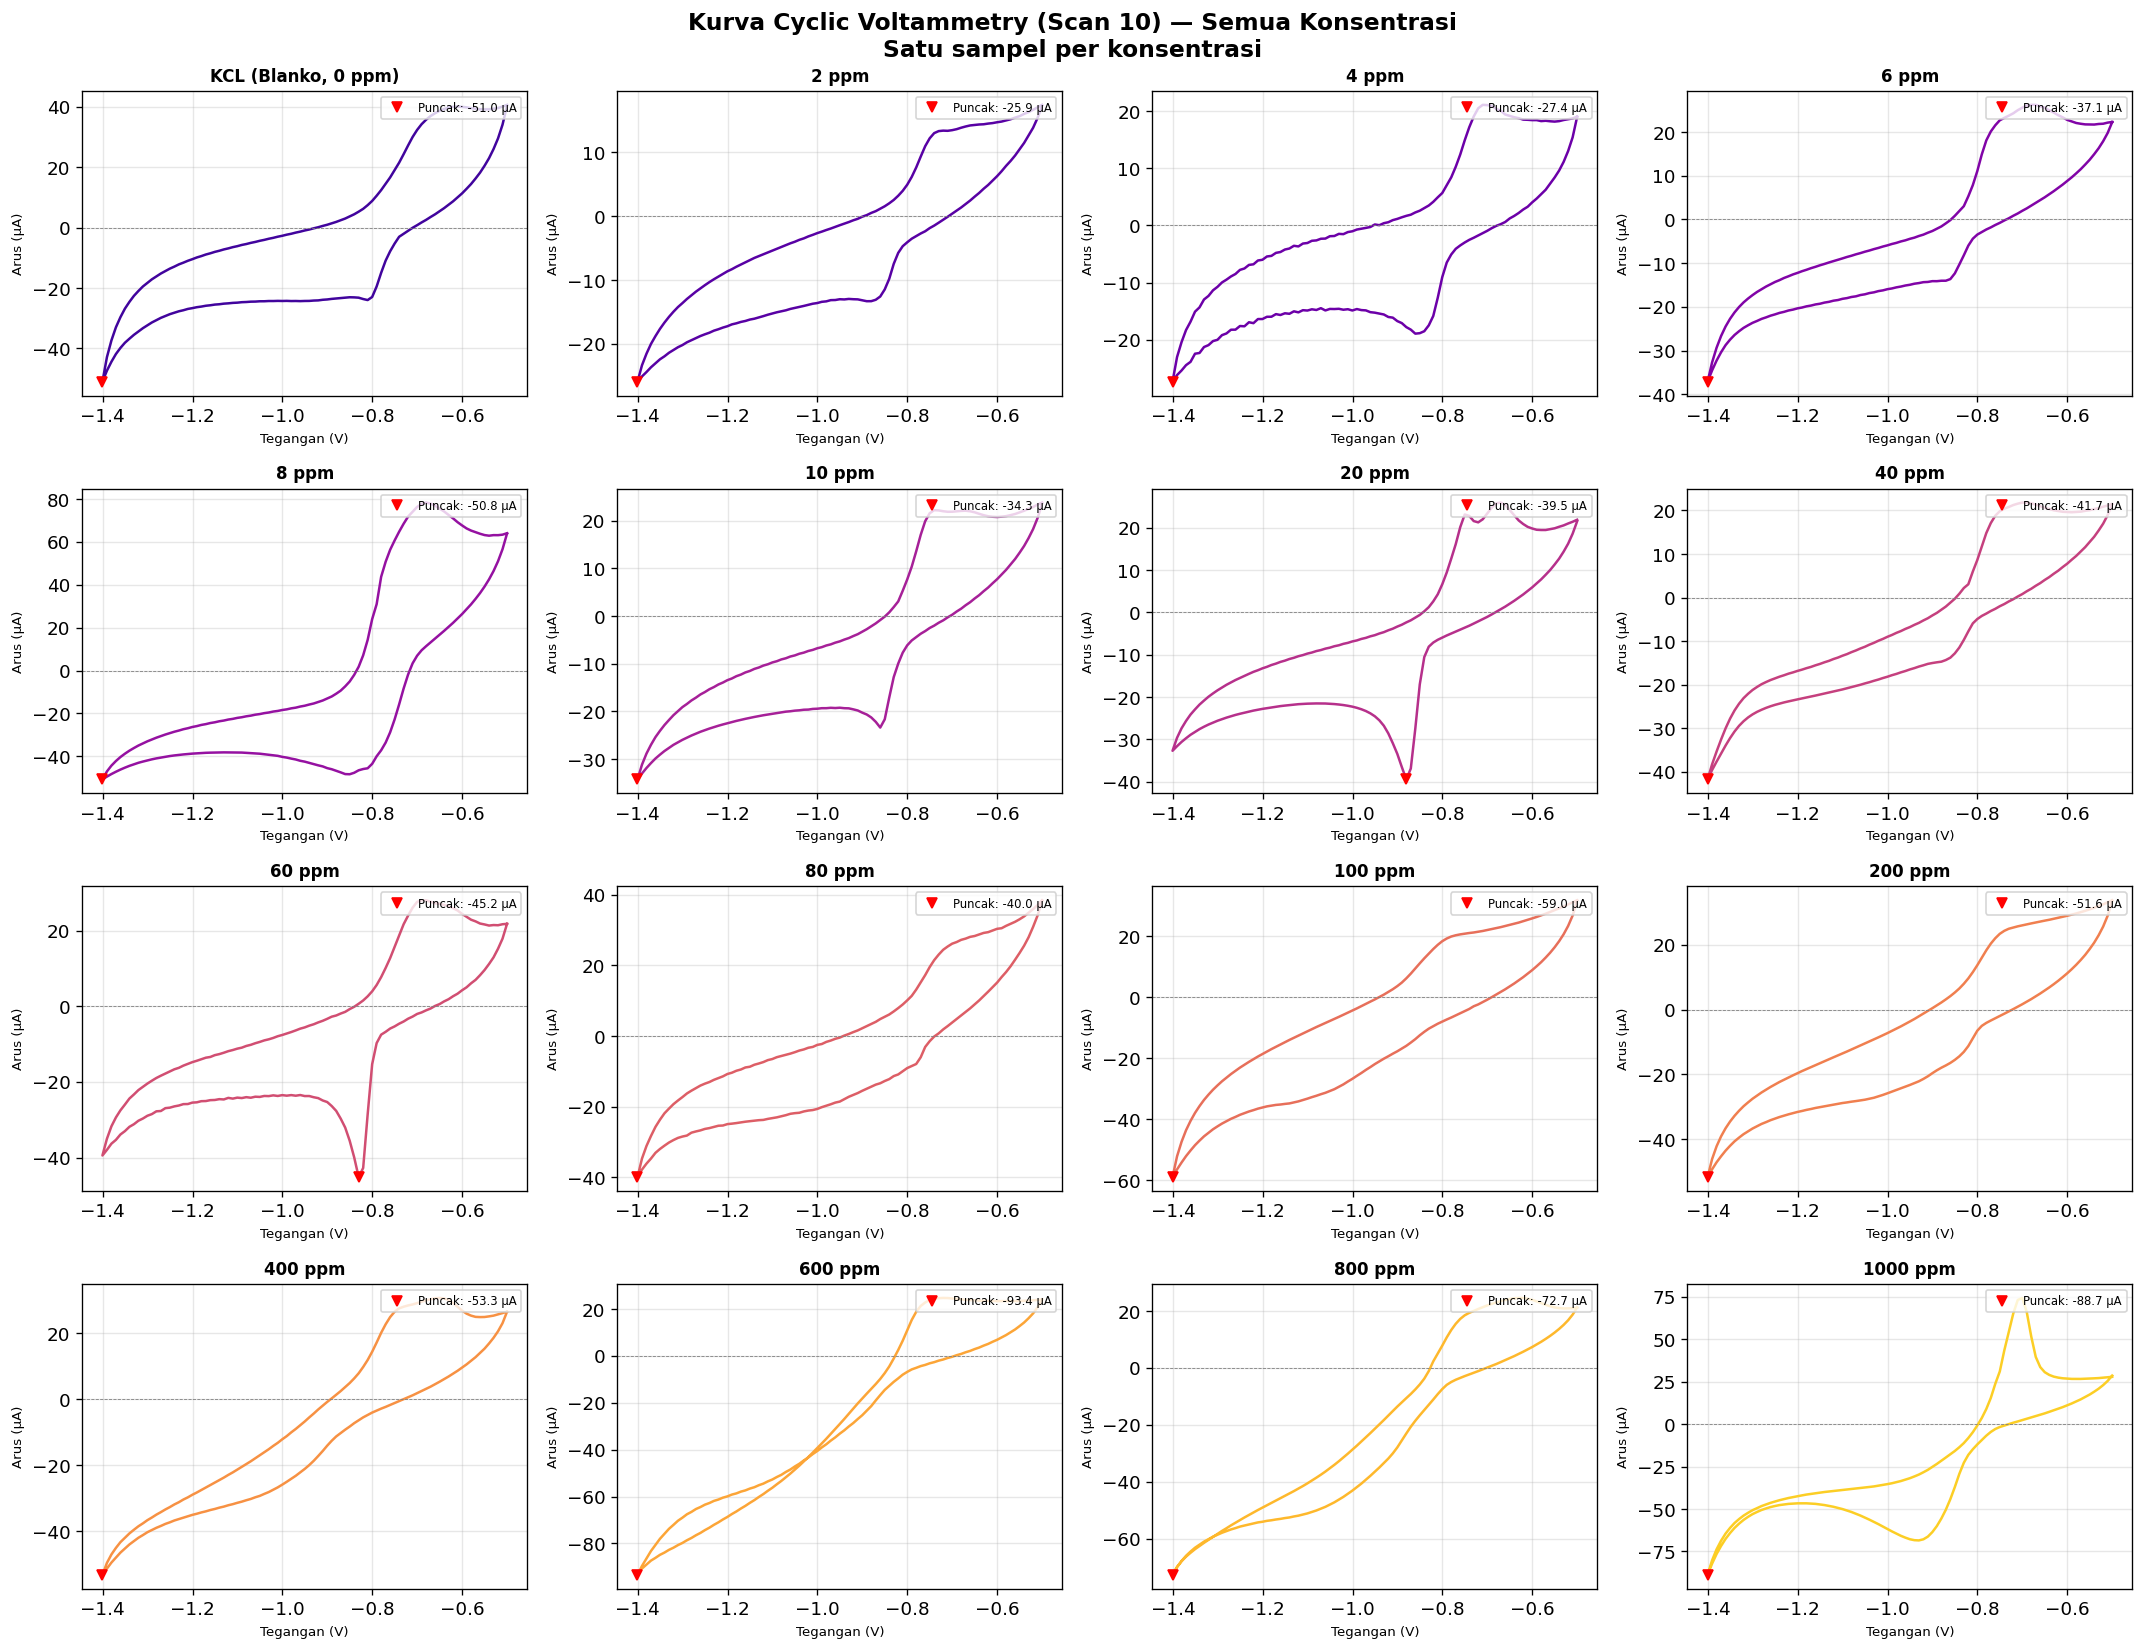

✅ Grafik disimpan sebagai plot_cv_semua_konsentrasi.png


In [7]:
# ======================================================
# PLOT 1: Kurva CV Scan 10 — Semua Konsentrasi
# ======================================================

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle('Kurva Cyclic Voltammetry (Scan 10) — Semua Konsentrasi\n'
             'Satu sampel per konsentrasi', fontsize=14, fontweight='bold', y=0.98)

# Warna berbeda untuk setiap konsentrasi
colors = cm.plasma(np.linspace(0.1, 0.9, 16))

for idx, (folder_name, color) in enumerate(zip(urutan_folder, colors)):
    ax = axes[idx // 4][idx % 4]

    if folder_name not in folder_info:
        ax.set_visible(False)
        continue

    # Ambil satu sampel (file pertama) dari konsentrasi ini
    subset = df_raw[df_raw['folder'] == folder_name]
    if len(subset) == 0:
        ax.set_visible(False)
        continue

    row    = subset.iloc[0]
    v      = row['s10_voltage']
    a      = row['s10_current']
    ppm    = row['ppm']
    label  = 'KCL (Blanko, 0 ppm)' if folder_name == 'KCL' else f'{ppm} ppm'

    ax.plot(v, a, color=color, linewidth=1.5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tegangan (V)', fontsize=8)
    ax.set_ylabel('Arus (µA)', fontsize=8)
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')

    # Tandai titik puncak arus minimum (puncak reduksi)
    idx_min = np.argmin(a)
    ax.plot(v[idx_min], a[idx_min], 'rv', markersize=6, label=f'Puncak: {a[idx_min]:.1f} µA')
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('plot_cv_semua_konsentrasi.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Grafik disimpan sebagai plot_cv_semua_konsentrasi.png')

## 📈 SEL 8 — Visualisasi Perbandingan Antar Konsentrasi (1 Grafik)

Sekarang kita plot semua konsentrasi dalam **satu grafik** agar bisa melihat
bagaimana kurva CV berubah seiring naiknya konsentrasi Kadmium.

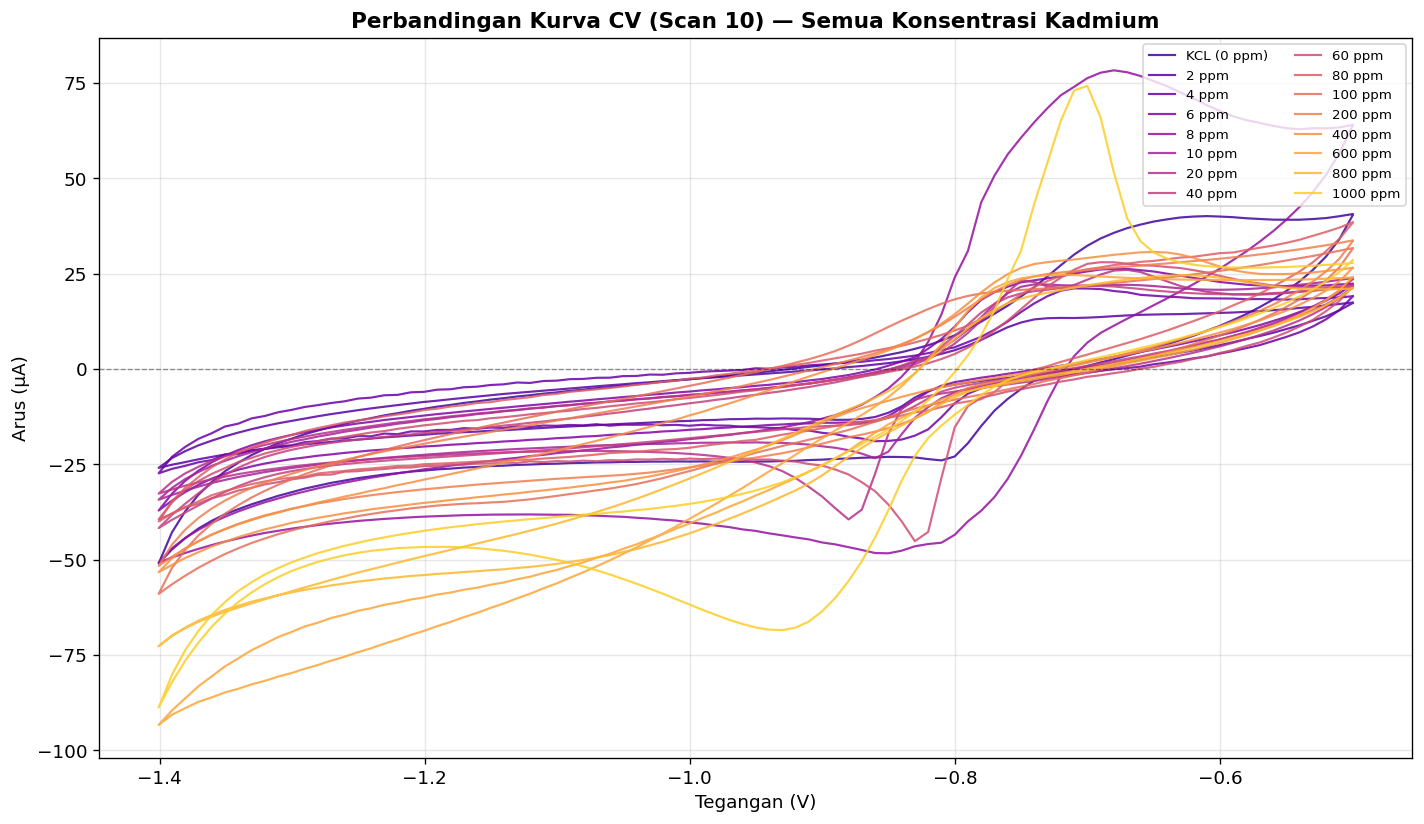

✅ Grafik disimpan sebagai plot_cv_overlay.png


In [8]:
# ======================================================
# PLOT 2: Overlay Semua Konsentrasi dalam Satu Grafik
# ======================================================

fig, ax = plt.subplots(figsize=(12, 7))

colors_overlay = cm.plasma(np.linspace(0.1, 0.9, len(urutan_folder)))

for folder_name, color in zip(urutan_folder, colors_overlay):
    if folder_name not in folder_info:
        continue
    subset = df_raw[df_raw['folder'] == folder_name]
    if len(subset) == 0:
        continue

    row   = subset.iloc[0]
    v     = row['s10_voltage']
    a     = row['s10_current']
    ppm   = row['ppm']
    label = 'KCL (0 ppm)' if folder_name == 'KCL' else f'{ppm} ppm'

    ax.plot(v, a, color=color, linewidth=1.3, label=label, alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_title('Perbandingan Kurva CV (Scan 10) — Semua Konsentrasi Kadmium',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tegangan (V)', fontsize=11)
ax.set_ylabel('Arus (µA)', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_cv_overlay.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Grafik disimpan sebagai plot_cv_overlay.png')

## 📈 SEL 9 — Visualisasi Semua Scan dalam Satu File

Kita lihat bagaimana kurva **Scan 1 sampai Scan 10 berubah** dalam satu file pengukuran.
Ini menunjukkan proses stabilisasi sensor — scan awal biasanya lebih 'berisik',
scan akhir lebih stabil. Itulah mengapa kita pakai Scan 10 sebagai representasi.

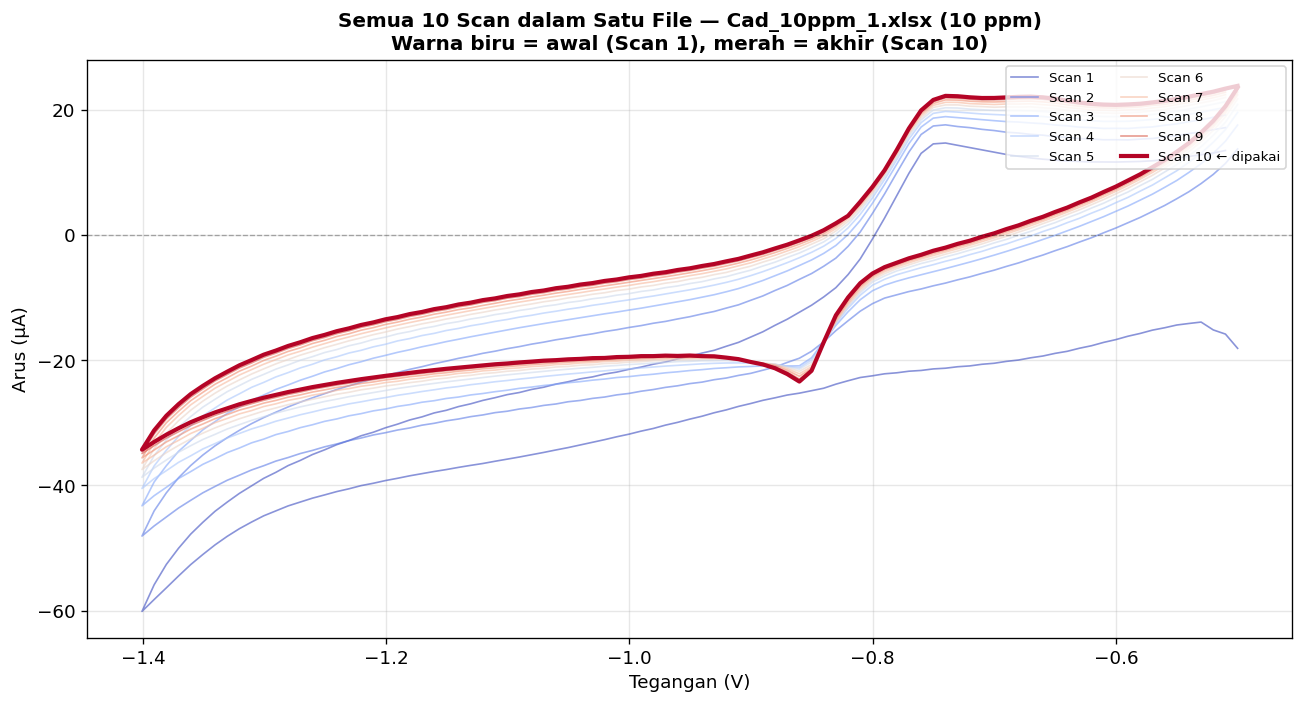

✅ Grafik disimpan sebagai plot_semua_scan.png

💡 INTERPRETASI:
   Scan 1 berbeda jauh dari scan-scan berikutnya → sensor sedang "pemanasan"
   Scan 7–10 sudah sangat berdekatan → sensor sudah stabil
   Maka Scan 10 adalah representasi terbaik dari kondisi sensor!


In [9]:
# ======================================================
# PLOT 3: Semua Scan dalam Satu File (10 ppm, file pertama)
# ======================================================

fig, ax = plt.subplots(figsize=(11, 6))

row_contoh = df_raw[df_raw['folder'] == '10'].iloc[0]
colors_scan = cm.coolwarm(np.linspace(0, 1, 10))

for i, color in zip(range(1, 11), colors_scan):
    v = row_contoh[f's{i}_voltage']
    a = row_contoh[f's{i}_current']
    lw = 2.5 if i == 10 else 1.0
    alpha = 1.0 if i == 10 else 0.6
    ax.plot(v, a, color=color, linewidth=lw, alpha=alpha,
            label=f'Scan {i}' + (' ← dipakai' if i == 10 else ''))

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
ax.set_title(f'Semua 10 Scan dalam Satu File — {row_contoh["filename"]} (10 ppm)\n'
             'Warna biru = awal (Scan 1), merah = akhir (Scan 10)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tegangan (V)', fontsize=11)
ax.set_ylabel('Arus (µA)', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_semua_scan.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Grafik disimpan sebagai plot_semua_scan.png')
print()
print('💡 INTERPRETASI:')
print('   Scan 1 berbeda jauh dari scan-scan berikutnya → sensor sedang "pemanasan"')
print('   Scan 7–10 sudah sangat berdekatan → sensor sudah stabil')
print('   Maka Scan 10 adalah representasi terbaik dari kondisi sensor!')

## 📈 SEL 10 — Statistik Puncak Arus per Konsentrasi

Kita hitung **arus puncak (peak current)** dari Scan 10 untuk semua file,
lalu tampilkan statistiknya per konsentrasi.

Ini adalah eksplorasi awal untuk melihat apakah arus puncak bisa membedakan konsentrasi.

In [10]:
# ======================================================
# HITUNG PUNCAK ARUS (PEAK CURRENT) TIAP FILE
# ======================================================

# Hitung arus puncak minimum (puncak reduksi) dari Scan 10 setiap file
df_raw['peak_current_s10'] = df_raw['s10_current'].apply(lambda a: np.min(a))
df_raw['peak_voltage_s10'] = df_raw.apply(
    lambda row: row['s10_voltage'][np.argmin(row['s10_current'])], axis=1
)

# Statistik per konsentrasi
stats = df_raw.groupby('ppm')['peak_current_s10'].agg(['mean','std','min','max','count'])
stats.columns = ['Rata-rata (µA)', 'Std Dev', 'Min (µA)', 'Maks (µA)', 'Jumlah File']
stats = stats.reset_index()

print('📊 STATISTIK PUNCAK ARUS (Peak Current) SCAN 10 PER KONSENTRASI')
print('='*75)
print(f'{'PPM':>6} | {'Rata-rata (µA)':>15} | {'Std Dev':>9} | {'Min (µA)':>10} | {'Maks (µA)':>10} | {'N':>5}')
print('='*75)
for _, r in stats.iterrows():
    print(f'{int(r["ppm"]):>6} | {r["Rata-rata (µA)"]:>15.3f} | {r["Std Dev"]:>9.3f} | {r["Min (µA)"]:>10.3f} | {r["Maks (µA)"]:>10.3f} | {int(r["Jumlah File"]):>5}')
print('='*75)

📊 STATISTIK PUNCAK ARUS (Peak Current) SCAN 10 PER KONSENTRASI
   PPM |  Rata-rata (µA) |   Std Dev |   Min (µA) |  Maks (µA) |     N
     0 |         -37.281 |     4.477 |    -51.425 |    -29.677 |    50
     2 |         -24.611 |     1.665 |    -29.113 |    -22.053 |    50
     4 |         -25.200 |     1.179 |    -29.001 |    -23.758 |    50
     6 |         -31.900 |     2.329 |    -37.127 |    -28.240 |    50
     8 |         -33.184 |     3.959 |    -50.758 |    -29.827 |    50
    10 |         -37.207 |     9.440 |    -54.253 |    -27.883 |    50
    20 |         -50.673 |    10.245 |    -68.203 |    -34.468 |    50
    40 |         -46.264 |     4.242 |    -67.809 |    -39.767 |    50
    60 |         -37.545 |     3.820 |    -47.601 |    -33.829 |    49
    80 |         -42.909 |     1.908 |    -46.728 |    -40.001 |    48
   100 |         -47.272 |     6.506 |    -73.887 |    -42.247 |    50
   200 |         -45.780 |     1.985 |    -51.641 |    -43.496 |    50
   400 |      

## 📈 SEL 11 — Grafik Tren Puncak Arus vs Konsentrasi

Visualisasi paling penting: apakah ada **hubungan/tren** antara konsentrasi Cd
dan arus puncak yang dihasilkan sensor?

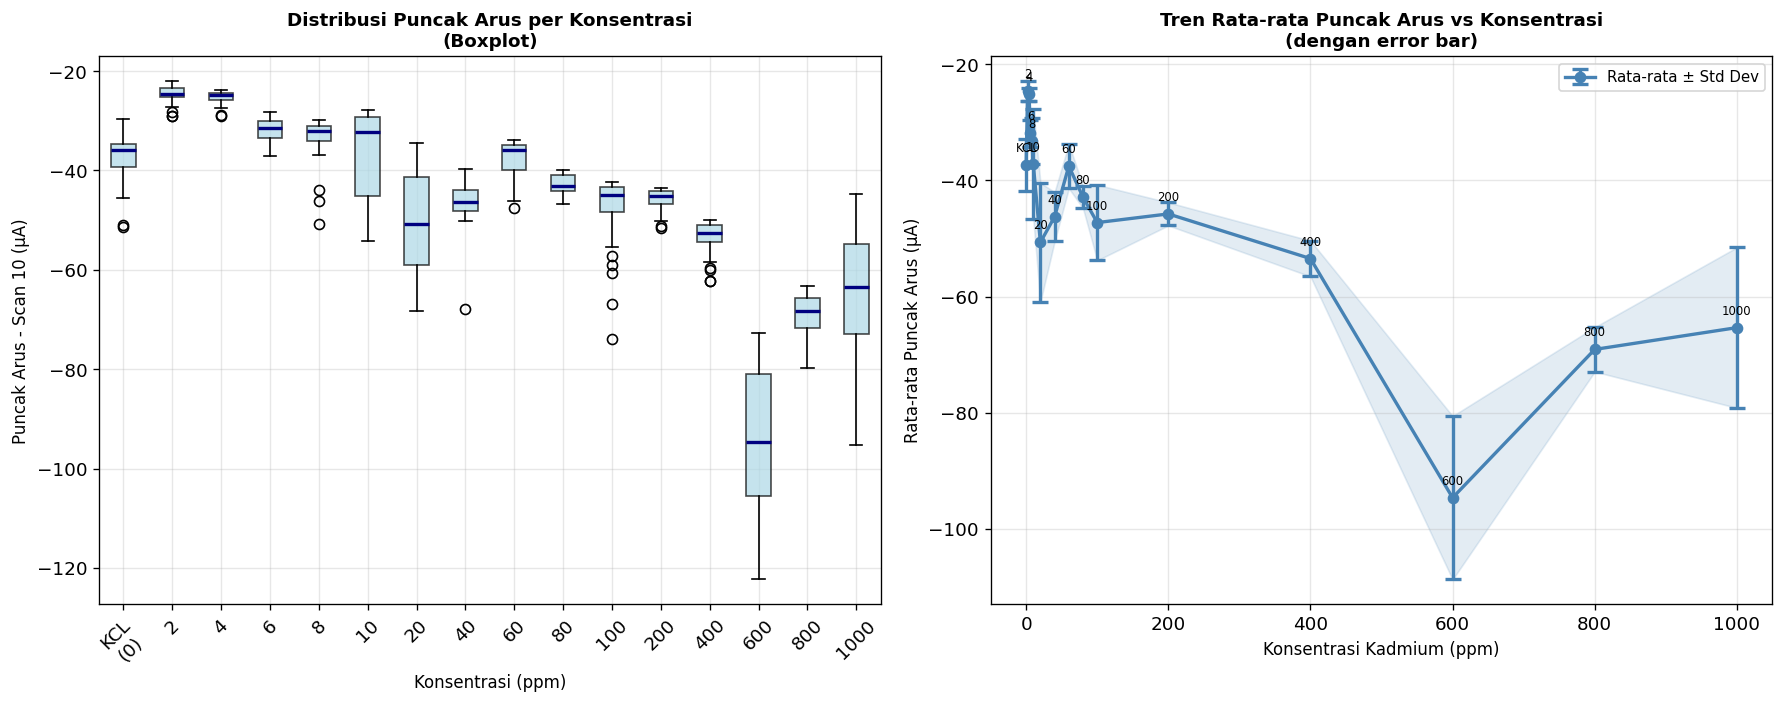

✅ Grafik disimpan sebagai plot_tren_peak_current.png


In [11]:
# ======================================================
# PLOT 4: Tren Peak Current vs Konsentrasi
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Grafik kiri: Boxplot distribusi per konsentrasi ---
ax1 = axes[0]
ppm_groups = [df_raw[df_raw['ppm'] == ppm]['peak_current_s10'].values
              for ppm in sorted(df_raw['ppm'].unique())]
ppm_labels = [str(int(p)) if p > 0 else 'KCL\n(0)'
              for p in sorted(df_raw['ppm'].unique())]

bp = ax1.boxplot(ppm_groups, labels=ppm_labels, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='navy', linewidth=2))
ax1.set_title('Distribusi Puncak Arus per Konsentrasi\n(Boxplot)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Konsentrasi (ppm)', fontsize=10)
ax1.set_ylabel('Puncak Arus - Scan 10 (µA)', fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# --- Grafik kanan: Rata-rata ± Std Dev ---
ax2 = axes[1]
ppm_vals = stats['ppm'].values
means    = stats['Rata-rata (µA)'].values
stds     = stats['Std Dev'].values

ax2.errorbar(ppm_vals, means, yerr=stds, fmt='o-', color='steelblue',
             capsize=5, capthick=2, linewidth=2, markersize=6, label='Rata-rata ± Std Dev')
ax2.fill_between(ppm_vals, means - stds, means + stds, alpha=0.15, color='steelblue')
ax2.set_title('Tren Rata-rata Puncak Arus vs Konsentrasi\n(dengan error bar)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Konsentrasi Kadmium (ppm)', fontsize=10)
ax2.set_ylabel('Rata-rata Puncak Arus (µA)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Tambahkan label konsentrasi
for x, y in zip(ppm_vals, means):
    label = 'KCL' if x == 0 else str(int(x))
    ax2.annotate(label, (x, y), textcoords='offset points', xytext=(0, 8), fontsize=7, ha='center')

plt.tight_layout()
plt.savefig('plot_tren_peak_current.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Grafik disimpan sebagai plot_tren_peak_current.png')

## 💾 SEL 12 — Simpan Dataset untuk Tahap Berikutnya

Kita simpan `df_raw` agar bisa dipakai di Tahap 2 (Preprocessing) tanpa perlu
membaca ulang semua file dari awal.

> 💡 File `.pkl` adalah format Python yang bisa menyimpan array NumPy di dalam tabel pandas.

In [12]:
# ======================================================
# SIMPAN DATASET KE FILE
# ======================================================

# Simpan dalam format pickle (bisa simpan array numpy di dalam DataFrame)
df_raw.to_pickle('dataset_sensor_cd_raw.pkl')
print('✅ Dataset disimpan sebagai: dataset_sensor_cd_raw.pkl')

# Download otomatis ke komputer kamu
files.download('dataset_sensor_cd_raw.pkl')
files.download('plot_cv_semua_konsentrasi.png')
files.download('plot_cv_overlay.png')
files.download('plot_semua_scan.png')
files.download('plot_tren_peak_current.png')

print()
print('📦 File yang didownload:')
print('   - dataset_sensor_cd_raw.pkl  → dataset utama (untuk Tahap 2)')
print('   - plot_cv_semua_konsentrasi.png → grafik CV 16 konsentrasi')
print('   - plot_cv_overlay.png           → grafik overlay semua konsentrasi')
print('   - plot_semua_scan.png           → grafik 10 scan dalam 1 file')
print('   - plot_tren_peak_current.png    → grafik tren puncak arus vs konsentrasi')

✅ Dataset disimpan sebagai: dataset_sensor_cd_raw.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 File yang didownload:
   - dataset_sensor_cd_raw.pkl  → dataset utama (untuk Tahap 2)
   - plot_cv_semua_konsentrasi.png → grafik CV 16 konsentrasi
   - plot_cv_overlay.png           → grafik overlay semua konsentrasi
   - plot_semua_scan.png           → grafik 10 scan dalam 1 file
   - plot_tren_peak_current.png    → grafik tren puncak arus vs konsentrasi


## ✅ SEL 13 — Rangkuman Tahap 1

Jalankan sel ini untuk melihat ringkasan akhir dari semua yang sudah dikerjakan.

In [13]:
# ======================================================
# RANGKUMAN AKHIR TAHAP 1
# ======================================================

print('=' * 60)
print('  ✅ TAHAP 1 SELESAI — RINGKASAN HASIL')
print('=' * 60)
print()
print('📁 DATA YANG BERHASIL DIBACA:')
print(f'   • Total file         : {len(df_raw)}')
print(f'   • Total konsentrasi  : {df_raw["ppm"].nunique()} (termasuk KCL/blanko)')
print(f'   • Rentang konsentrasi: {int(df_raw[df_raw["ppm"]>0]["ppm"].min())} - {int(df_raw["ppm"].max())} ppm')
print(f'   • Scan per file      : 10 scan')
print(f'   • Titik data per scan: ~180 titik')
print()
print('📊 TEMUAN DARI EKSPLORASI DATA:')
print('   • Kurva CV berbentuk loop (forward + reverse sweep)')
print('   • Rentang tegangan: -0.5V sampai -1.4V (bukan +0.5V)')
print('   • Scan 10 dipilih karena paling stabil')
print('   • Puncak arus negatif = proses reduksi Kadmium')
print('   • Terdapat tren: puncak arus berubah seiring konsentrasi')
print()
print('📈 VISUALISASI YANG DIHASILKAN:')
print('   1. Kurva CV per konsentrasi (16 subplot)')
print('   2. Overlay semua konsentrasi dalam 1 grafik')
print('   3. Perubahan 10 scan dalam 1 file')
print('   4. Tren puncak arus vs konsentrasi (boxplot + error bar)')
print()
print('📝 OUTPUT FILE:')
print('   • dataset_sensor_cd_raw.pkl  (untuk dipakai di Tahap 2)')
print('   • 4 file grafik (.png)')
print()
print('🔜 TAHAP SELANJUTNYA: Preprocessing & Ekstraksi Fitur')
print('   (Filtering, smoothing, dan ekstraksi peak current,')
print('    peak voltage, serta area di bawah kurva / AUC)')
print('=' * 60)

  ✅ TAHAP 1 SELESAI — RINGKASAN HASIL

📁 DATA YANG BERHASIL DIBACA:
   • Total file         : 797
   • Total konsentrasi  : 16 (termasuk KCL/blanko)
   • Rentang konsentrasi: 2 - 1000 ppm
   • Scan per file      : 10 scan
   • Titik data per scan: ~180 titik

📊 TEMUAN DARI EKSPLORASI DATA:
   • Kurva CV berbentuk loop (forward + reverse sweep)
   • Rentang tegangan: -0.5V sampai -1.4V (bukan +0.5V)
   • Scan 10 dipilih karena paling stabil
   • Puncak arus negatif = proses reduksi Kadmium
   • Terdapat tren: puncak arus berubah seiring konsentrasi

📈 VISUALISASI YANG DIHASILKAN:
   1. Kurva CV per konsentrasi (16 subplot)
   2. Overlay semua konsentrasi dalam 1 grafik
   3. Perubahan 10 scan dalam 1 file
   4. Tren puncak arus vs konsentrasi (boxplot + error bar)

📝 OUTPUT FILE:
   • dataset_sensor_cd_raw.pkl  (untuk dipakai di Tahap 2)
   • 4 file grafik (.png)

🔜 TAHAP SELANJUTNYA: Preprocessing & Ekstraksi Fitur
   (Filtering, smoothing, dan ekstraksi peak current,
    peak voltage,

# TAHAP 2

Cell 1 — Import & Setup

In [14]:
import os
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
import warnings
warnings.filterwarnings('ignore')

# Path ke folder utama dataset
BASE_PATH = "Alat Sensor CD Groundturth"  # sesuaikan jika perlu

# Mapping folder → label konsentrasi (ppm)
# KCL dianggap 0 ppm (blanko/kontrol)
CONCENTRATION_MAP = {
    '2': 2, '4': 4, '6': 6, '8': 8,
    '10': 10, '20': 20, '40': 40, '60': 60, '80': 80,
    '100': 100, '200': 200, '400': 400, '600': 600,
    '800': 800, '1000': 1000, 'KCL': 0
}

print("✅ Import selesai")
print(f"Jumlah kelas konsentrasi: {len(CONCENTRATION_MAP)}")

✅ Import selesai
Jumlah kelas konsentrasi: 16


Cell 2 — Fungsi Baca 1 File CV

In [17]:
import os
import pandas as pd

# SESUAIKAN: Berdasarkan gambar, folder utama Anda adalah 'data_sensor'
BASE_PATH = "data_sensor/Alat Sensor CD Groundturth"

def read_cv_file(filepath):
    """
    Baca satu file xlsx CV.
    Return: dict {scan_1: (voltage, current), ..., scan_10: (voltage, current)}
    """
    # Pastikan file ada sebelum dibaca
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File tidak ditemukan di: {filepath}")

    df = pd.read_excel(filepath, header=None)

    scans = {}
    n_scans = df.shape[1] // 2

    for i in range(n_scans):
        col_v = i * 2
        col_i = i * 2 + 1

        # Ambil data, abaikan header (baris 0 dan 1)
        voltage = pd.to_numeric(df.iloc[2:, col_v], errors='coerce').dropna().values
        current = pd.to_numeric(df.iloc[2:, col_i], errors='coerce').dropna().values

        min_len = min(len(voltage), len(current))
        scans[f'scan_{i+1}'] = (voltage[:min_len], current[:min_len])

    return scans

# Test baca satu file dengan path yang sudah diperbaiki
try:
    test_file = os.path.join(BASE_PATH, "10", "Cad_10ppm_1.xlsx")
    print(f"Mencoba membaca: {test_file}")

    test_scans = read_cv_file(test_file)

    print(f"✅ File berhasil dibaca")
    print(f"Jumlah scan: {len(test_scans)}")
    print(f"Panjang scan_10: {len(test_scans['scan_10'][0])} titik")
    print(f"Rentang Voltage: {test_scans['scan_10'][0].min():.3f} V sampai {test_scans['scan_10'][0].max():.3f} V")

except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Saran: Gunakan !ls 'data_sensor/Alat Sensor CD Groundturth/10' untuk cek nama file.")

Mencoba membaca: data_sensor/Alat Sensor CD Groundturth/10/Cad_10ppm_1.xlsx
✅ File berhasil dibaca
Jumlah scan: 10
Panjang scan_10: 181 titik
Rentang Voltage: -1.401 V sampai -0.500 V


Cell 3 — Savitzky-Golay Filter (Smoothing/Filtering Noise)

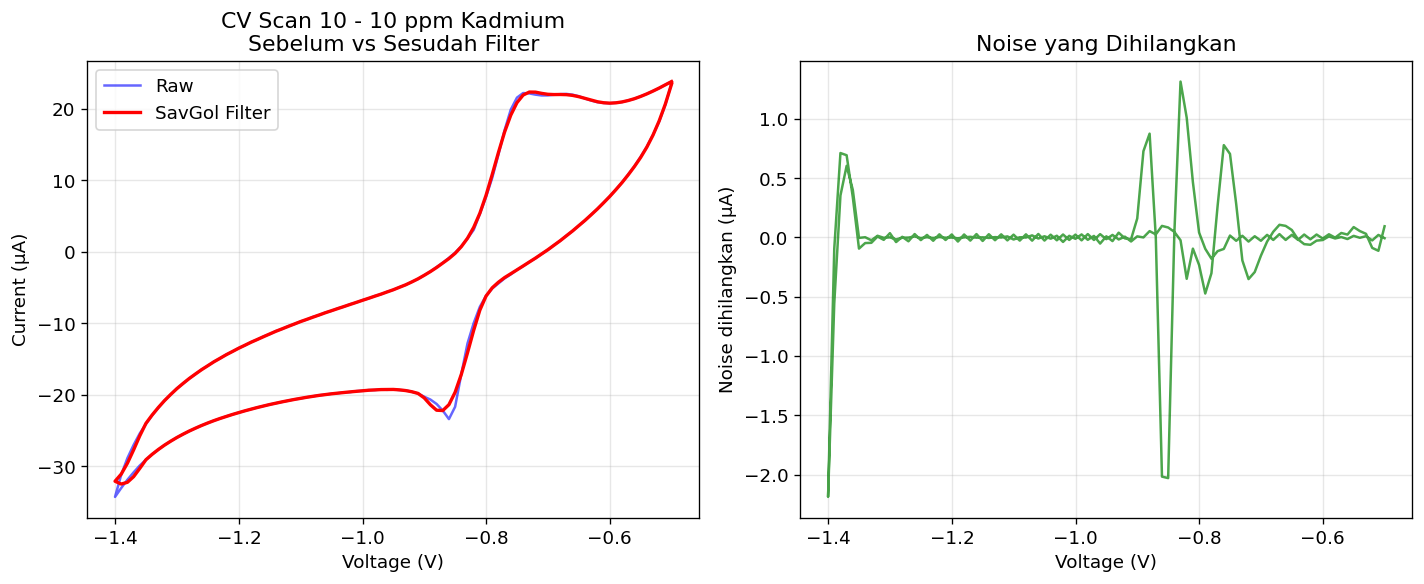

✅ Savitzky-Golay filter berhasil diaplikasikan


In [18]:
def apply_savgol_filter(current, window_length=11, polyorder=3):
    """
    Terapkan Savitzky-Golay filter pada sinyal arus.
    - window_length: harus ganjil, makin besar makin smooth
    - polyorder: orde polinomial (biasanya 2-4)
    """
    # Pastikan window tidak lebih panjang dari sinyal
    wl = min(window_length, len(current))
    if wl % 2 == 0:
        wl -= 1  # harus ganjil
    if wl <= polyorder:
        return current  # data terlalu pendek, skip filter

    return savgol_filter(current, window_length=wl, polyorder=polyorder)

# Visualisasi perbandingan sebelum vs sesudah filter
import matplotlib.pyplot as plt

voltage_raw, current_raw = test_scans['scan_10']
current_filtered = apply_savgol_filter(current_raw, window_length=11, polyorder=3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(voltage_raw, current_raw, 'b-', alpha=0.6, label='Raw')
plt.plot(voltage_raw, current_filtered, 'r-', linewidth=2, label='SavGol Filter')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (µA)')
plt.title('CV Scan 10 - 10 ppm Kadmium\nSebelum vs Sesudah Filter')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(voltage_raw, current_raw - current_filtered, 'g-', alpha=0.7)
plt.xlabel('Voltage (V)')
plt.ylabel('Noise dihilangkan (µA)')
plt.title('Noise yang Dihilangkan')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('savgol_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Savitzky-Golay filter berhasil diaplikasikan")

Cell 4 — Fungsi Ekstraksi Fitur (Feature Extraction)

In [19]:
def extract_features_from_file(filepath, use_last_scan=True):
    """
    Ekstrak fitur-fitur penting dari satu file CV.

    Fitur yang diekstrak:
    1. peak_current_max     : Nilai arus puncak tertinggi (µA)
    2. peak_current_min     : Nilai arus puncak terendah / paling negatif (µA)
    3. peak_voltage_max     : Tegangan saat arus puncak maksimum (V)
    4. peak_voltage_min     : Tegangan saat arus puncak minimum (V)
    5. delta_peak_current   : Selisih puncak anodik - katodik (µA)
    6. auc                  : Luas area di bawah kurva / AUC (µA·V)
    7. mean_current_last    : Rata-rata arus pada scan terakhir (µA)
    8. std_current_last     : Standar deviasi arus scan terakhir
    9. scan_stability       : Korelasi antara scan 9 dan scan 10 (stabilitas)
    10. half_wave_potential  : Potensial setengah gelombang (V)
    """
    try:
        scans = read_cv_file(filepath)
    except Exception as e:
        print(f"Error membaca {filepath}: {e}")
        return None

    # Gunakan scan terakhir (scan_10) — paling stabil
    scan_key = 'scan_10' if use_last_scan else 'scan_1'
    voltage, current_raw = scans[scan_key]

    # Terapkan SavGol filter
    current = apply_savgol_filter(current_raw, window_length=11, polyorder=3)

    features = {}

    # 1 & 3. Peak Current Maximum (anodik) dan voltagenya
    idx_max = np.argmax(current)
    features['peak_current_max'] = current[idx_max]
    features['peak_voltage_max'] = voltage[idx_max]

    # 2 & 4. Peak Current Minimum (katodik) dan voltagenya
    idx_min = np.argmin(current)
    features['peak_current_min'] = current[idx_min]
    features['peak_voltage_min'] = voltage[idx_min]

    # 5. Delta peak (perbedaan anodik-katodik → terkait reversibilitas reaksi)
    features['delta_peak_current'] = features['peak_current_max'] - features['peak_current_min']

    # 6. Area Under Curve (AUC) menggunakan integrasi trapesium
    features['auc'] = float(np.abs(trapezoid(current, voltage)))

    # 7 & 8. Statistik arus scan terakhir
    features['mean_current_last'] = float(np.mean(current))
    features['std_current_last'] = float(np.std(current))

    # 9. Stabilitas scan (korelasi scan_9 vs scan_10)
    if 'scan_9' in scans and 'scan_10' in scans:
        _, curr9 = scans['scan_9']
        _, curr10 = scans['scan_10']
        min_len = min(len(curr9), len(curr10))
        if min_len > 5:
            corr = np.corrcoef(curr9[:min_len], curr10[:min_len])[0, 1]
            features['scan_stability'] = float(corr) if not np.isnan(corr) else 0.0
        else:
            features['scan_stability'] = 0.0
    else:
        features['scan_stability'] = 0.0

    # 10. Half-wave potential: tegangan saat arus = setengah dari peak max
    half_wave_current = features['peak_current_max'] / 2
    idx_half = np.argmin(np.abs(current - half_wave_current))
    features['half_wave_potential'] = float(voltage[idx_half])

    return features

# Test ekstraksi fitur pada 1 file
test_features = extract_features_from_file(test_file)
print("✅ Fitur berhasil diekstrak dari 1 file:")
for k, v in test_features.items():
    print(f"  {k:25s} = {v:.4f}")

✅ Fitur berhasil diekstrak dari 1 file:
  peak_current_max          = 23.7958
  peak_voltage_max          = -0.5000
  peak_current_min          = -32.4922
  peak_voltage_min          = -1.3907
  delta_peak_current        = 56.2880
  auc                       = 11.2800
  mean_current_last         = -6.4832
  std_current_last          = 16.6036
  scan_stability            = 1.0000
  half_wave_potential       = -0.5600


Cell 5 — Load Semua Data & Bangun Dataset

In [20]:
def build_dataset(base_path, concentration_map, verbose=True):
    """
    Iterasi semua folder konsentrasi, baca semua file xlsx,
    ekstrak fitur, dan kembalikan sebagai DataFrame.
    """
    all_features = []

    for folder, concentration in concentration_map.items():
        folder_path = os.path.join(base_path, folder)

        if not os.path.isdir(folder_path):
            if verbose:
                print(f"⚠️  Folder tidak ditemukan: {folder_path}")
            continue

        xlsx_files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]

        if verbose:
            print(f"📂 {folder:6s} ({concentration:5d} ppm) → {len(xlsx_files)} file", end="")

        count_ok = 0
        for fname in xlsx_files:
            fpath = os.path.join(folder_path, fname)
            features = extract_features_from_file(fpath)

            if features is not None:
                features['concentration_ppm'] = concentration
                features['folder'] = folder
                features['filename'] = fname
                all_features.append(features)
                count_ok += 1

        if verbose:
            print(f" → {count_ok} berhasil diproses ✅")

    df = pd.DataFrame(all_features)
    return df

# Build dataset (ini akan memakan waktu ~1-2 menit)
print("🔄 Memproses semua file...\n")
df_features = build_dataset(BASE_PATH, CONCENTRATION_MAP)

print(f"\n✅ Dataset selesai dibuat!")
print(f"Total sampel  : {len(df_features)}")
print(f"Jumlah fitur  : {len(df_features.columns) - 3}")  # kurangi kolom metadata
print(f"\nDistribusi per kelas:")
print(df_features.groupby('concentration_ppm').size().to_string())

🔄 Memproses semua file...

📂 2      (    2 ppm) → 50 file → 50 berhasil diproses ✅
📂 4      (    4 ppm) → 50 file → 50 berhasil diproses ✅
📂 6      (    6 ppm) → 50 file → 50 berhasil diproses ✅
📂 8      (    8 ppm) → 50 file → 50 berhasil diproses ✅
📂 10     (   10 ppm) → 50 file → 50 berhasil diproses ✅
📂 20     (   20 ppm) → 50 file → 50 berhasil diproses ✅
📂 40     (   40 ppm) → 50 file → 50 berhasil diproses ✅
📂 60     (   60 ppm) → 49 file → 49 berhasil diproses ✅
📂 80     (   80 ppm) → 48 file → 48 berhasil diproses ✅
📂 100    (  100 ppm) → 50 file → 50 berhasil diproses ✅
📂 200    (  200 ppm) → 50 file → 50 berhasil diproses ✅
📂 400    (  400 ppm) → 50 file → 50 berhasil diproses ✅
📂 600    (  600 ppm) → 50 file → 50 berhasil diproses ✅
📂 800    (  800 ppm) → 50 file → 50 berhasil diproses ✅
📂 1000   ( 1000 ppm) → 50 file → 50 berhasil diproses ✅
📂 KCL    (    0 ppm) → 50 file → 50 berhasil diproses ✅

✅ Dataset selesai dibuat!
Total sampel  : 797
Jumlah fitur  : 10

Distribusi

Cell 6 — Cek Kualitas Data & Simpan

In [21]:
# Kolom fitur saja (tanpa metadata)
feature_cols = [
    'peak_current_max', 'peak_current_min', 'peak_voltage_max',
    'peak_voltage_min', 'delta_peak_current', 'auc',
    'mean_current_last', 'std_current_last', 'scan_stability',
    'half_wave_potential'
]

print("📊 Statistik Deskriptif Fitur:")
print(df_features[feature_cols].describe().round(4))

print(f"\n🔍 Cek Missing Values:")
print(df_features[feature_cols].isnull().sum())

# Tangani jika ada NaN
df_features[feature_cols] = df_features[feature_cols].fillna(df_features[feature_cols].median())
print("\n✅ Missing values ditangani (fill dengan median)")

# Simpan dataset hasil preprocessing
df_features.to_csv('dataset_features_tahap2.csv', index=False)
print("💾 Dataset disimpan ke: dataset_features_tahap2.csv")
print(f"\nShape final: {df_features.shape}")

📊 Statistik Deskriptif Fitur:
       peak_current_max  peak_current_min  peak_voltage_max  peak_voltage_min  \
count          797.0000          797.0000          797.0000          797.0000   
mean            30.7924          -43.0684           -0.6047           -1.3126   
std             12.0022           17.2157            0.0872            0.1854   
min             17.4228         -112.4084           -0.7702           -1.4007   
25%             23.4136          -48.4164           -0.6801           -1.3907   
50%             28.9877          -40.1699           -0.6401           -1.3907   
75%             33.5846          -30.9766           -0.5000           -1.3807   
max            116.7381          -20.9882           -0.5000           -0.7602   

       delta_peak_current       auc  mean_current_last  std_current_last  \
count            797.0000  797.0000           797.0000          797.0000   
mean              73.8608   12.7132            -7.5207           20.7208   
std         

Cell 7 — Visualisasi Distribusi Fitur per Konsentrasi

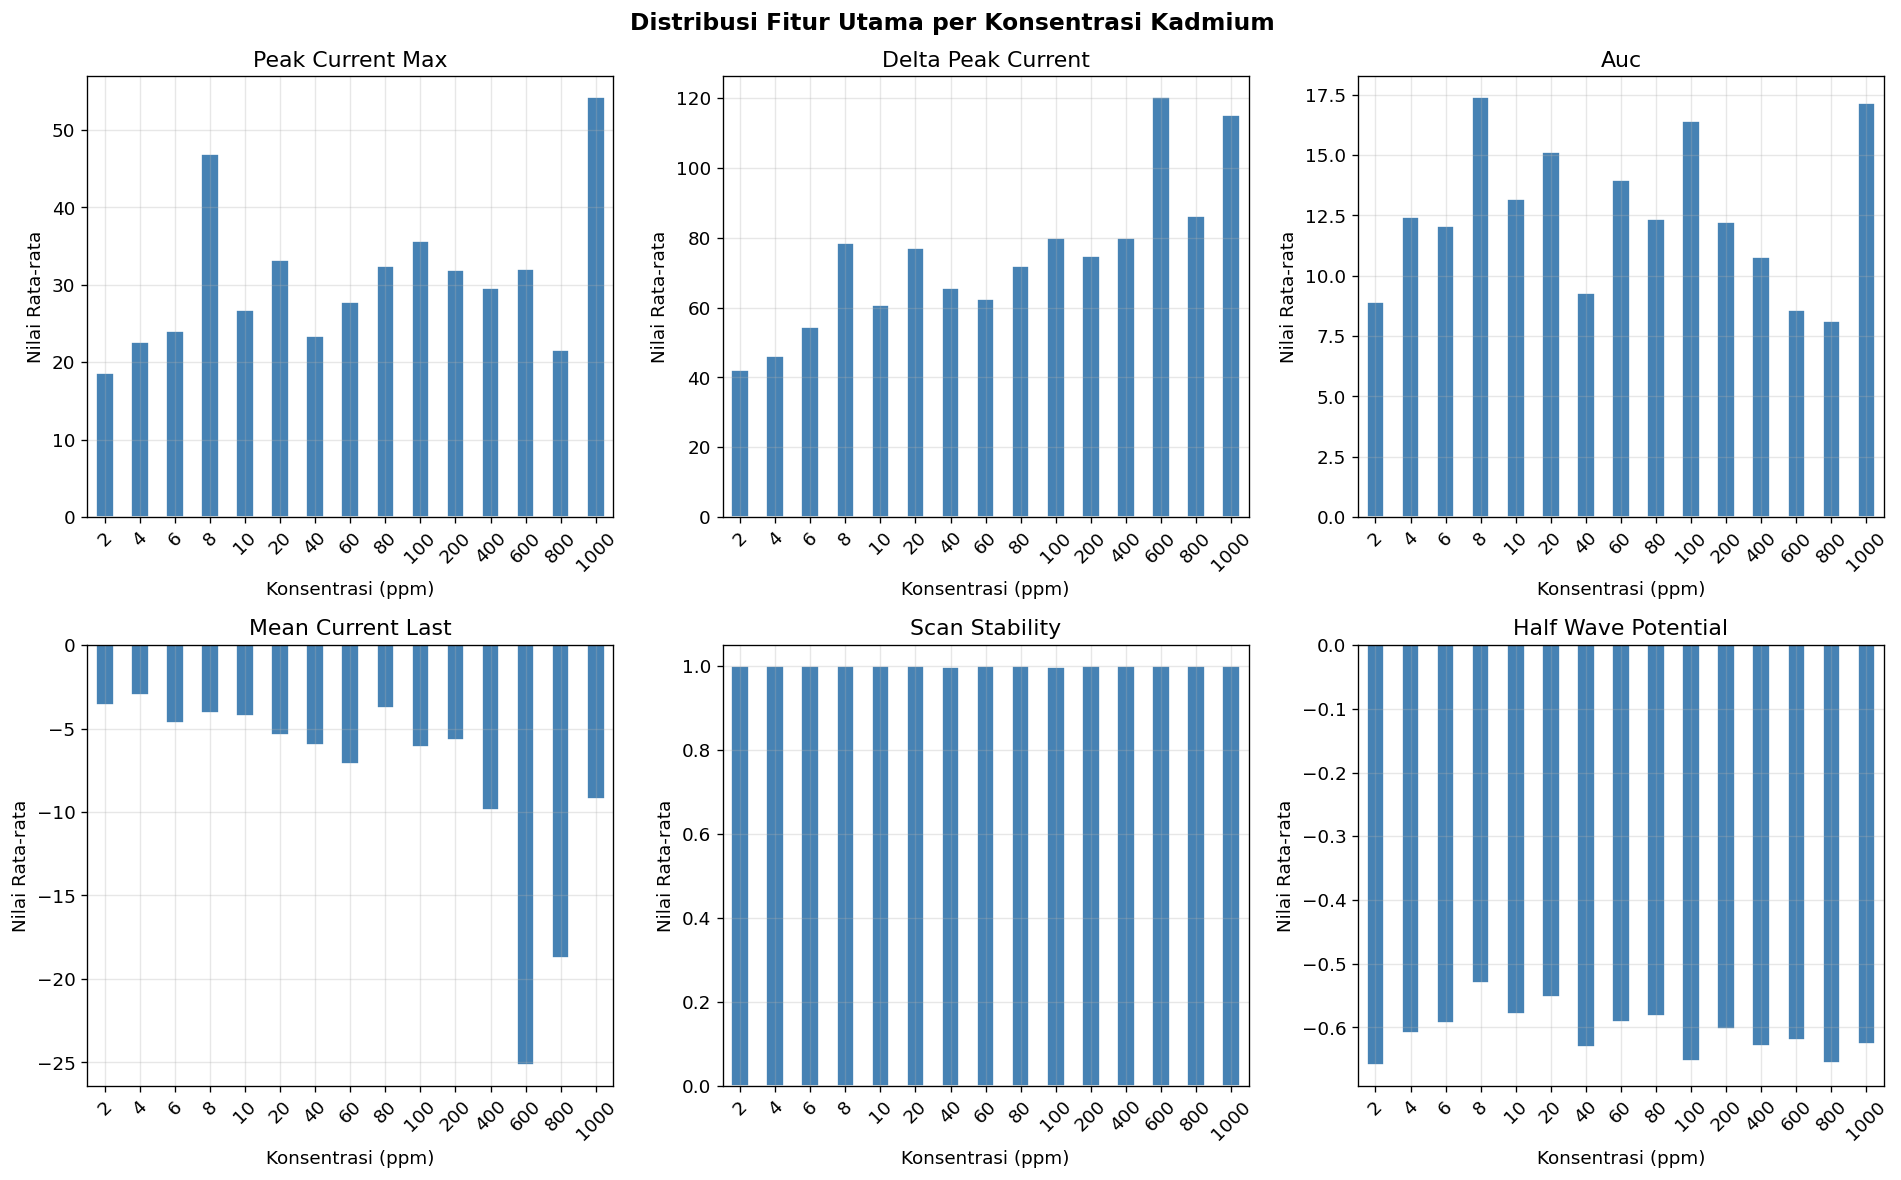

✅ Visualisasi disimpan


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur Utama per Konsentrasi Kadmium', fontsize=14, fontweight='bold')

plot_features = ['peak_current_max', 'delta_peak_current', 'auc',
                 'mean_current_last', 'scan_stability', 'half_wave_potential']

for ax, feat in zip(axes.flatten(), plot_features):
    # Hanya tampilkan konsentrasi selain KCL (0 ppm) agar lebih jelas
    df_plot = df_features[df_features['concentration_ppm'] > 0]

    df_plot.groupby('concentration_ppm')[feat].mean().plot(
        kind='bar', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Konsentrasi (ppm)')
    ax.set_ylabel('Nilai Rata-rata')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fitur_distribusi_per_konsentrasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi disimpan")

# TAHAP 3 DAN 4

Cell 8 — Load Dataset & Persiapan

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load hasil Tahap 2
df = pd.read_csv('dataset_features_tahap2.csv')

feature_cols = [
    'peak_current_max', 'peak_current_min', 'peak_voltage_max',
    'peak_voltage_min', 'delta_peak_current', 'auc',
    'mean_current_last', 'std_current_last', 'scan_stability',
    'half_wave_potential'
]

X = df[feature_cols].values
y = df['concentration_ppm'].values

print(f"✅ Dataset loaded: {X.shape[0]} sampel, {X.shape[1]} fitur")
print(f"Target range: {y.min()} - {y.max()} ppm")
print(f"Distribusi kelas:\n{pd.Series(y).value_counts().sort_index()}")

✅ Dataset loaded: 797 sampel, 10 fitur
Target range: 0 - 1000 ppm
Distribusi kelas:
0       50
2       50
4       50
6       50
8       50
10      50
20      50
40      50
60      49
80      48
100     50
200     50
400     50
600     50
800     50
1000    50
Name: count, dtype: int64


Cell 9 — Split Data & Scaling

In [24]:
# Split 80% train, 20% test — stratified supaya semua konsentrasi terwakili
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=pd.cut(y, bins=8, labels=False)  # stratify berdasarkan range ppm
)

# Scaling (penting untuk SVR & Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Data split selesai")
print(f"Training set : {X_train.shape[0]} sampel")
print(f"Test set     : {X_test.shape[0]} sampel")

✅ Data split selesai
Training set : 637 sampel
Test set     : 160 sampel


Cell 10 — Train 4 Model & Evaluasi

In [25]:
# Definisi semua model
models = {
    'Linear Regression':    LinearRegression(),
    'Random Forest':        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=200, random_state=42, learning_rate=0.05),
    'SVR':                  SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
}

results = {}

print("="*65)
print(f"{'Model':<22} {'MAE':>8} {'MSE':>12} {'RMSE':>10} {'R²':>8}")
print("="*65)

for name, model in models.items():
    # Linear Regression & SVR butuh scaled data
    if name in ['Linear Regression', 'SVR']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results[name] = {
        'model': model, 'y_pred': y_pred,
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2
    }

    print(f"{name:<22} {mae:>8.2f} {mse:>12.2f} {rmse:>10.2f} {r2:>8.4f}")

print("="*65)

# Tentukan model terbaik berdasarkan R²
best_model_name = max(results, key=lambda k: results[k]['R2'])
print(f"\n🏆 Model terbaik: {best_model_name}")
print(f"   R² = {results[best_model_name]['R2']:.4f}")
print(f"   MAE = {results[best_model_name]['MAE']:.2f} ppm")

Model                       MAE          MSE       RMSE       R²
Linear Regression        118.80     29540.08     171.87   0.6908
Random Forest             29.26      5798.12      76.15   0.9393
Gradient Boosting         40.54      7075.94      84.12   0.9259
SVR                       47.56     15185.47     123.23   0.8411

🏆 Model terbaik: Random Forest
   R² = 0.9393
   MAE = 29.26 ppm


Cell 11 — Cross Validation (Validasi Lebih Robust)

In [26]:
print("🔄 5-Fold Cross Validation...\n")
print(f"{'Model':<22} {'CV R² Mean':>12} {'CV R² Std':>12}")
print("-"*48)

for name, model in models.items():
    if name in ['Linear Regression', 'SVR']:
        X_cv, y_cv = X_train_scaled, y_train
    else:
        X_cv, y_cv = X_train, y_train

    cv_scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='r2')
    print(f"{name:<22} {cv_scores.mean():>12.4f} {cv_scores.std():>12.4f}")

print("\n✅ Cross validation selesai")

🔄 5-Fold Cross Validation...

Model                    CV R² Mean    CV R² Std
------------------------------------------------
Linear Regression            0.6062       0.0887
Random Forest                0.8585       0.0466
Gradient Boosting            0.8732       0.0617
SVR                          0.8050       0.0993

✅ Cross validation selesai


Cell 12 — TAHAP 4: Grafik Prediksi vs Aktual (Semua Model)

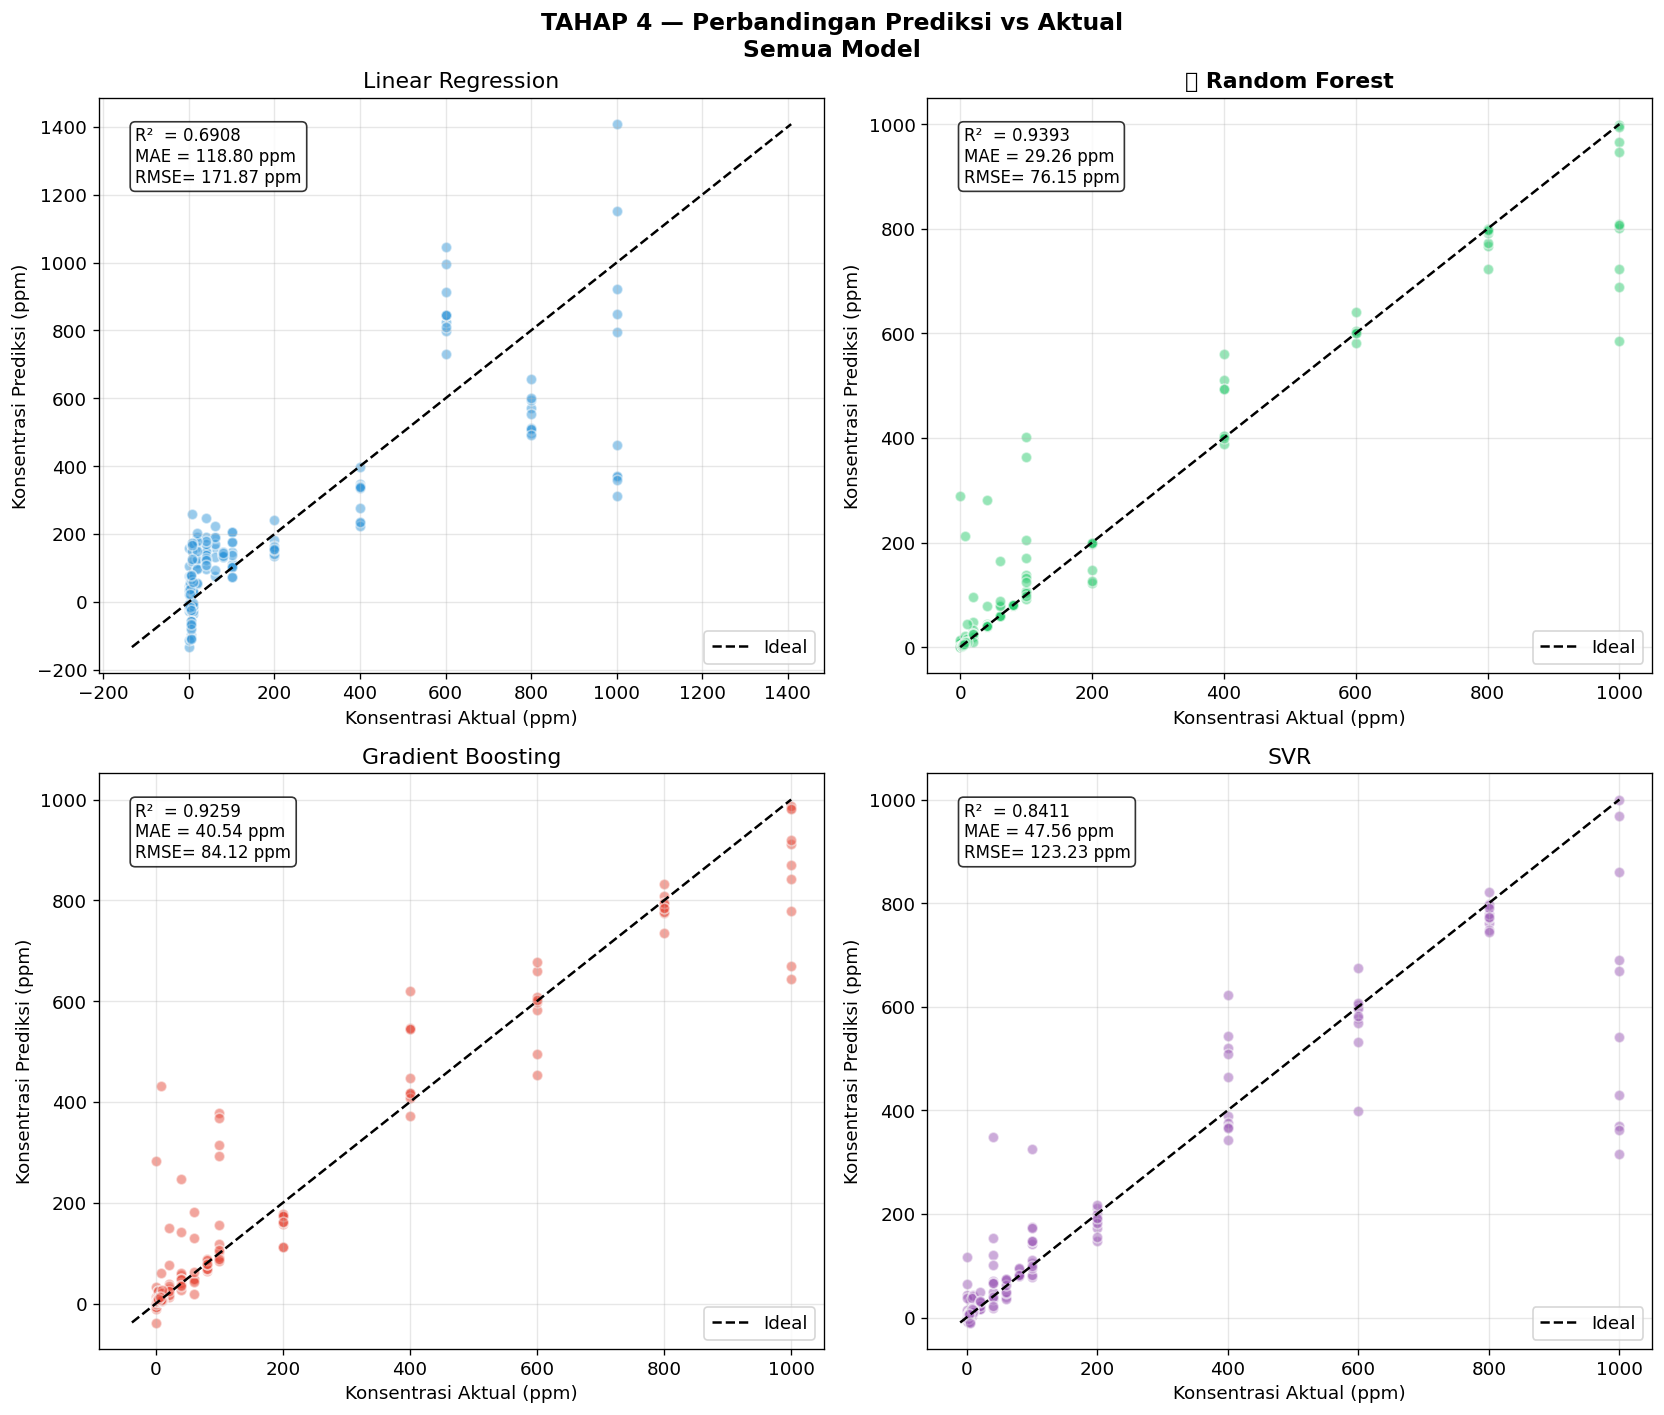

✅ Grafik disimpan: tahap4_prediksi_vs_aktual.png


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('TAHAP 4 — Perbandingan Prediksi vs Aktual\nSemua Model',
             fontsize=14, fontweight='bold')

colors = {'Linear Regression': '#3498db', 'Random Forest': '#2ecc71',
          'Gradient Boosting': '#e74c3c', 'SVR': '#9b59b6'}

for ax, (name, res) in zip(axes.flatten(), results.items()):
    y_pred = res['y_pred']
    color  = colors[name]

    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolors='white', s=40)

    # Garis ideal (perfect prediction)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal')

    # Anotasi metrik
    ax.text(0.05, 0.95,
        f"R²  = {res['R2']:.4f}\nMAE = {res['MAE']:.2f} ppm\nRMSE= {res['RMSE']:.2f} ppm",
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Highlight best model
    title = f"{'⭐ ' if name == best_model_name else ''}{name}"
    ax.set_title(title, fontweight='bold' if name == best_model_name else 'normal')
    ax.set_xlabel('Konsentrasi Aktual (ppm)')
    ax.set_ylabel('Konsentrasi Prediksi (ppm)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tahap4_prediksi_vs_aktual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: tahap4_prediksi_vs_aktual.png")

Cell 13 — Grafik Residual & Error Distribution

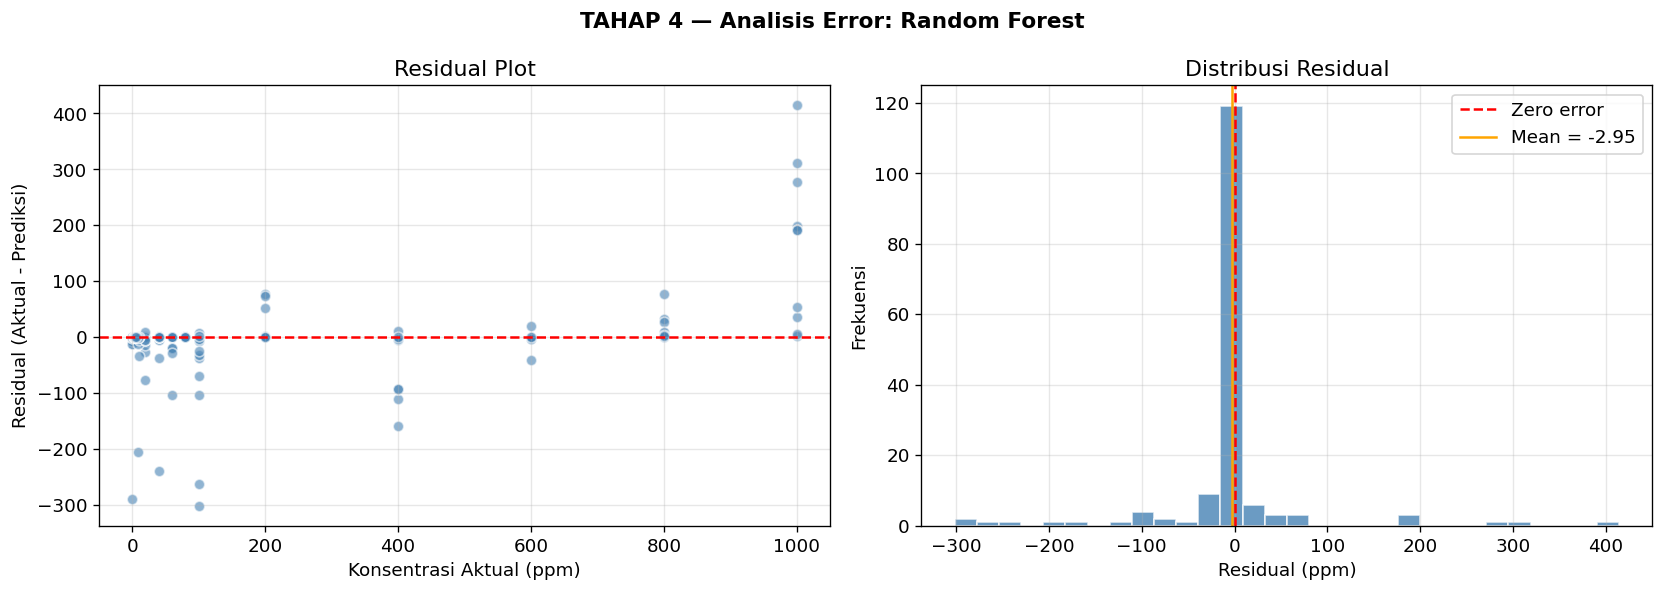

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'TAHAP 4 — Analisis Error: {best_model_name}', fontsize=13, fontweight='bold')

best_pred = results[best_model_name]['y_pred']
residuals = y_test - best_pred

# Plot 1: Residual vs Actual
axes[0].scatter(y_test, residuals, alpha=0.6, color='steelblue', edgecolors='white', s=40)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Konsentrasi Aktual (ppm)')
axes[0].set_ylabel('Residual (Aktual - Prediksi)')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribusi Error
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='-', linewidth=1.5,
                label=f'Mean = {residuals.mean():.2f}')
axes[1].set_xlabel('Residual (ppm)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tahap4_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 14 — Tabel Ringkasan Akhir + Feature Importance


📊 RINGKASAN EVALUASI MODEL — TAHAP 3 & 4
                  MAE (ppm)       MSE RMSE (ppm) R² Score
Linear Regression    118.80  29540.08     171.87   0.6908
Random Forest         29.26   5798.12      76.15   0.9393
Gradient Boosting     40.54   7075.94      84.12   0.9259
SVR                   47.56  15185.47     123.23   0.8411

🏆 Model Terbaik: Random Forest (R² = 0.9393)


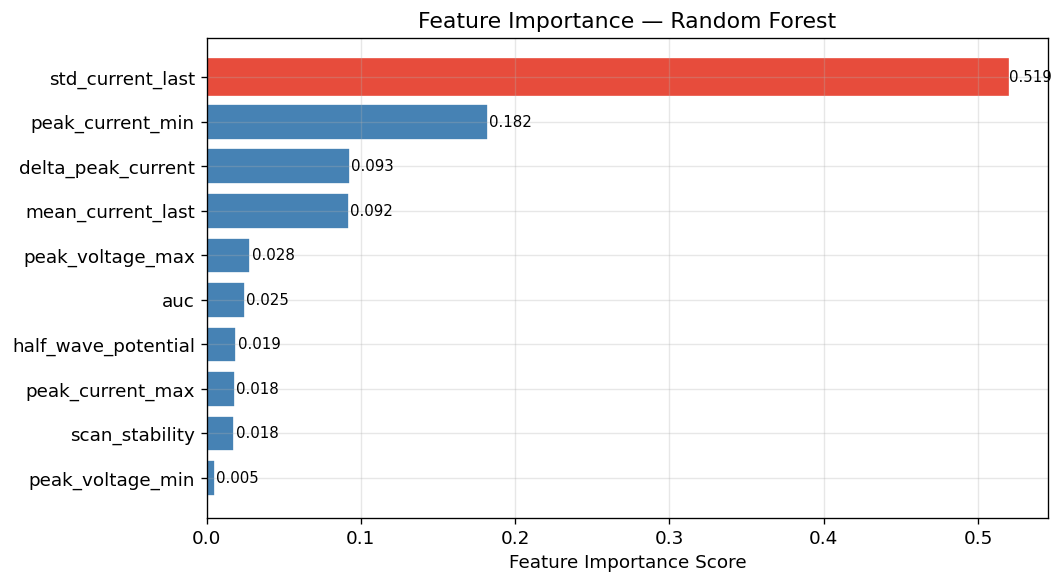


✅ Fitur paling penting: std_current_last


In [30]:
# Tabel ringkasan semua model
print("\n" + "="*65)
print("📊 RINGKASAN EVALUASI MODEL — TAHAP 3 & 4")
print("="*65)
summary_df = pd.DataFrame({
    name: {'MAE (ppm)': f"{res['MAE']:.2f}",
           'MSE': f"{res['MSE']:.2f}",
           'RMSE (ppm)': f"{res['RMSE']:.2f}",
           'R² Score': f"{res['R2']:.4f}"}
    for name, res in results.items()
}).T
print(summary_df.to_string())
print("="*65)
print(f"\n🏆 Model Terbaik: {best_model_name} (R² = {results[best_model_name]['R2']:.4f})")

# Feature Importance (khusus Random Forest atau Gradient Boosting)
tree_model_name = 'Random Forest' if results['Random Forest']['R2'] >= results['Gradient Boosting']['R2'] \
                  else 'Gradient Boosting'
tree_model = results[tree_model_name]['model']

importances = tree_model.feature_importances_
feat_imp_df = pd.DataFrame({'Fitur': feature_cols, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(feat_imp_df['Fitur'], feat_imp_df['Importance'],
                color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title(f'Feature Importance — {tree_model_name}')

# Highlight fitur terpenting
max_imp = feat_imp_df['Importance'].max()
for bar, imp in zip(bars, feat_imp_df['Importance']):
    if imp == max_imp:
        bar.set_color('#e74c3c')
    plt.text(imp + 0.001, bar.get_y() + bar.get_height()/2,
             f'{imp:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('tahap4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Fitur paling penting: {feat_imp_df.iloc[-1]['Fitur']}")